# Phase 7 — Publication Figures and Tables

This notebook creates the final figures and tables for the research report.

It does not:

- redefine collapse events,
- recompute or retune the detector,
- change the warning threshold,
- alter event matching,
- or replace previously saved results.

Every figure and table is generated from outputs saved by the earlier notebooks.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path(
    "/content/drive/MyDrive/When_Do_Factor_Premia_Break"
)

PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "data" / "results"
FIGURES = ROOT / "figures"
TABLES = ROOT / "tables"

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

print("Figures:", FIGURES)
print("Tables:", TABLES)

Mounted at /content/drive
Figures: /content/drive/MyDrive/When_Do_Factor_Premia_Break/figures
Tables: /content/drive/MyDrive/When_Do_Factor_Premia_Break/tables


In [2]:
FACTOR_INPUT = (
    PROCESSED / "factor_returns_daily.parquet"
)

COLLAPSE_STATISTICS_INPUT = (
    RESULTS / "collapse_statistics_daily.parquet"
)

COLLAPSE_EVENTS_INPUT = (
    RESULTS / "collapse_events.csv"
)

DEVELOPMENT_SCORES_INPUT = (
    RESULTS
    / "momentum_development_fragility_scores.parquet"
)

DEVELOPMENT_RESULTS_INPUT = (
    RESULTS
    / "momentum_development_threshold_results.csv"
)

FROZEN_CONFIG_INPUT = (
    RESULTS / "frozen_diagnostic_parameters.json"
)

HOLDOUT_FRAGILITY_INPUT = (
    RESULTS / "holdout_fragility_scores.parquet"
)

HOLDOUT_EVENTS_INPUT = (
    RESULTS / "holdout_event_results.csv"
)

HOLDOUT_WARNINGS_INPUT = (
    RESULTS / "holdout_warning_results.csv"
)

FACTOR_METRICS_INPUT = (
    RESULTS / "holdout_factor_metrics.csv"
)

POOLED_METRICS_INPUT = (
    RESULTS / "holdout_pooled_metrics.csv"
)

APPENDIX_POOLED_INPUT = (
    RESULTS / "appendix_warning_summary_pooled.csv"
)

BOOTSTRAP_INPUT = (
    RESULTS / "statistical_bootstrap_summary.csv"
)

PERMUTATION_INPUT = (
    RESULTS / "statistical_permutation_summary.csv"
)

FACTOR_VALIDATION_INPUT = (
    RESULTS / "statistical_factor_validation.csv"
)

HORIZON_SENSITIVITY_INPUT = (
    RESULTS / "statistical_horizon_sensitivity.csv"
)

NULL_DISTRIBUTIONS_INPUT = (
    RESULTS / "statistical_null_distributions.parquet"
)

VIX_BASELINE_INPUT = (
    RESULTS / "vix_baseline_comparison.csv"
)

VIX_FACTOR_INPUT = (
    RESULTS / "vix_factor_comparison.csv"
)

VIX_OVERLAP_INPUT = (
    RESULTS / "vix_overlap_summary.csv"
)

DETECTOR_SENSITIVITY_INPUT = (
    RESULTS / "detector_sensitivity_results.csv"
)

In [3]:
factors = pd.read_parquet(
    FACTOR_INPUT
)

collapse_statistics = pd.read_parquet(
    COLLAPSE_STATISTICS_INPUT
)

collapse_events = pd.read_csv(
    COLLAPSE_EVENTS_INPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
    ],
)

development_scores = pd.read_parquet(
    DEVELOPMENT_SCORES_INPUT
)

development_results = pd.read_csv(
    DEVELOPMENT_RESULTS_INPUT,
    parse_dates=[
        "first_qualifying_warning",
    ],
)

with open(
    FROZEN_CONFIG_INPUT,
    "r",
    encoding="utf-8",
) as file:
    frozen_config = json.load(file)

holdout_fragility = pd.read_parquet(
    HOLDOUT_FRAGILITY_INPUT
)

holdout_events = pd.read_csv(
    HOLDOUT_EVENTS_INPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
        "warning_window_start",
        "matched_warning_date",
    ],
)

holdout_warnings = pd.read_csv(
    HOLDOUT_WARNINGS_INPUT,
    parse_dates=["warning_date"],
)

factor_metrics = pd.read_csv(
    FACTOR_METRICS_INPUT
)

pooled_metrics = pd.read_csv(
    POOLED_METRICS_INPUT
)

appendix_pooled = pd.read_csv(
    APPENDIX_POOLED_INPUT
)

bootstrap_summary = pd.read_csv(
    BOOTSTRAP_INPUT
)

permutation_summary = pd.read_csv(
    PERMUTATION_INPUT
)

factor_validation = pd.read_csv(
    FACTOR_VALIDATION_INPUT
)

horizon_sensitivity = pd.read_csv(
    HORIZON_SENSITIVITY_INPUT
)

null_distributions = pd.read_parquet(
    NULL_DISTRIBUTIONS_INPUT
)

vix_baseline = pd.read_csv(
    VIX_BASELINE_INPUT,
    parse_dates=[
        "common_sample_start",
        "common_sample_end",
    ],
)

vix_factor = pd.read_csv(
    VIX_FACTOR_INPUT
)

vix_overlap = pd.read_csv(
    VIX_OVERLAP_INPUT
)

detector_sensitivity = pd.read_csv(
    DETECTOR_SENSITIVITY_INPUT
)

print("✓ All saved results loaded")

✓ All saved results loaded


In [4]:
FACTOR_COLUMNS = [
    "MKT_RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
    "MOM",
]

WARNING_THRESHOLD = float(
    frozen_config["warning_threshold"]
)

DEVELOPMENT_COLLAPSE_START = pd.Timestamp(
    frozen_config["development_collapse_start"]
)

assert frozen_config["status"] == "FROZEN"

assert len(holdout_events) == int(
    pooled_metrics.loc[
        0,
        "holdout_collapse_events",
    ]
)

assert int(
    holdout_events["detected"].sum()
) == int(
    pooled_metrics.loc[
        0,
        "detected_events",
    ]
)

assert np.isclose(
    holdout_events["detected"].mean(),
    pooled_metrics.loc[0, "recall"],
)

print("✓ Headline results passed validation")

✓ Headline results passed validation


In [5]:
def save_figure(
    figure: plt.Figure,
    filename: str,
) -> None:
    """
    Save a figure as both PNG and PDF.
    """
    png_path = FIGURES / f"{filename}.png"
    pdf_path = FIGURES / f"{filename}.pdf"

    figure.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    figure.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print("Saved:", png_path.name)
    print("Saved:", pdf_path.name)

Saved: figure_01_research_design.png
Saved: figure_01_research_design.pdf


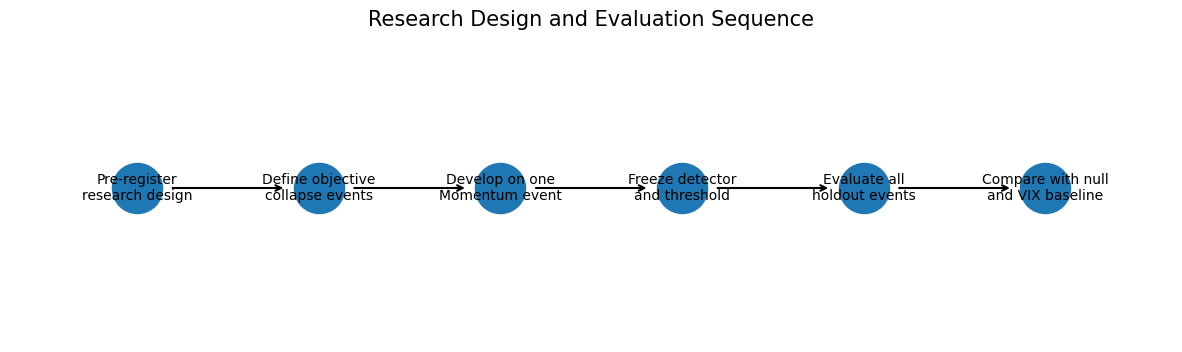

In [6]:
workflow_steps = [
    "Pre-register\nresearch design",
    "Define objective\ncollapse events",
    "Develop on one\nMomentum event",
    "Freeze detector\nand threshold",
    "Evaluate all\nholdout events",
    "Compare with null\nand VIX baseline",
]

x_positions = np.arange(
    len(workflow_steps)
)

fig, ax = plt.subplots(
    figsize=(15, 4)
)

ax.scatter(
    x_positions,
    np.zeros_like(x_positions),
    s=1300,
)

for position in range(
    len(workflow_steps) - 1
):
    ax.annotate(
        "",
        xy=(
            position + 0.82,
            0,
        ),
        xytext=(
            position + 0.18,
            0,
        ),
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.5,
        },
    )

for position, label in enumerate(
    workflow_steps
):
    ax.text(
        position,
        0,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

ax.set_xlim(
    -0.7,
    len(workflow_steps) - 0.3,
)

ax.set_ylim(
    -0.8,
    0.8,
)

ax.axis("off")

ax.set_title(
    "Research Design and Evaluation Sequence",
    fontsize=15,
)

save_figure(
    fig,
    "figure_01_research_design",
)

plt.show()

Saved: figure_02_collapse_timeline.png
Saved: figure_02_collapse_timeline.pdf


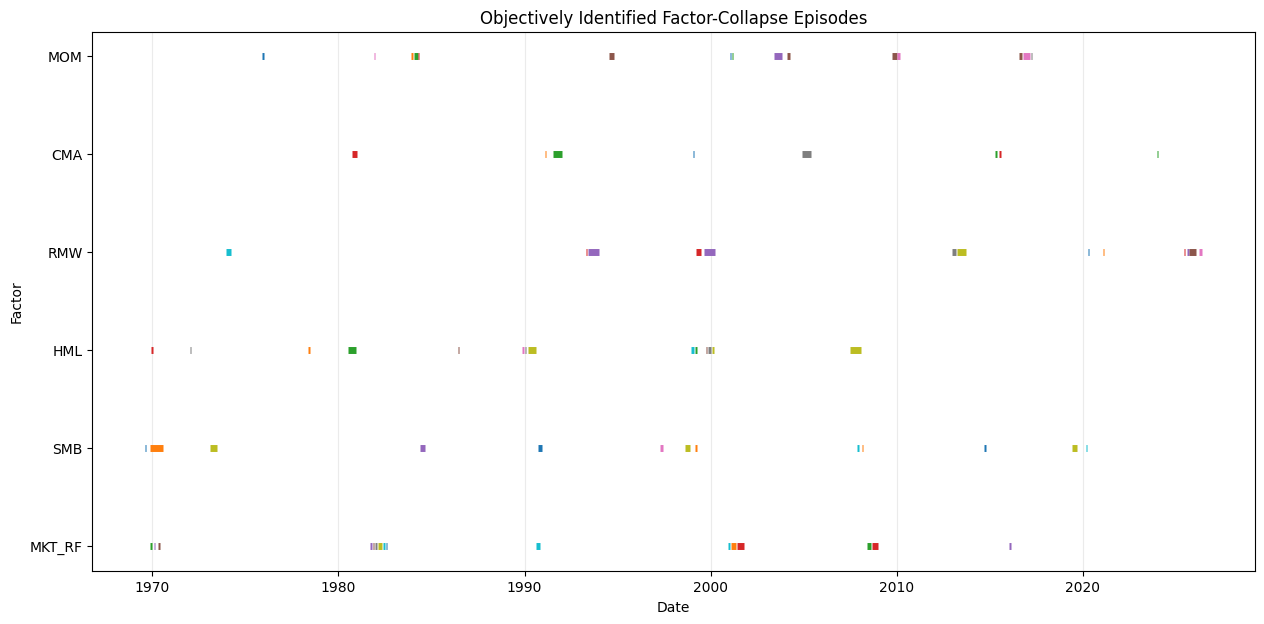

In [7]:
fig, ax = plt.subplots(
    figsize=(15, 7)
)

factor_positions = {
    factor: position
    for position, factor
    in enumerate(FACTOR_COLUMNS)
}

for event in collapse_events.itertuples(
    index=False
):
    y_position = factor_positions[
        event.factor
    ]

    ax.plot(
        [
            event.collapse_start,
            event.collapse_end,
        ],
        [
            y_position,
            y_position,
        ],
        linewidth=5,
        solid_capstyle="butt",
    )

ax.set_yticks(
    range(len(FACTOR_COLUMNS))
)

ax.set_yticklabels(
    FACTOR_COLUMNS
)

ax.set_xlabel("Date")
ax.set_ylabel("Factor")

ax.set_title(
    "Objectively Identified Factor-Collapse Episodes"
)

ax.xaxis.set_major_locator(
    mdates.YearLocator(10)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.grid(
    axis="x",
    alpha=0.25,
)

save_figure(
    fig,
    "figure_02_collapse_timeline",
)

plt.show()

Saved: figure_03_momentum_development.png
Saved: figure_03_momentum_development.pdf


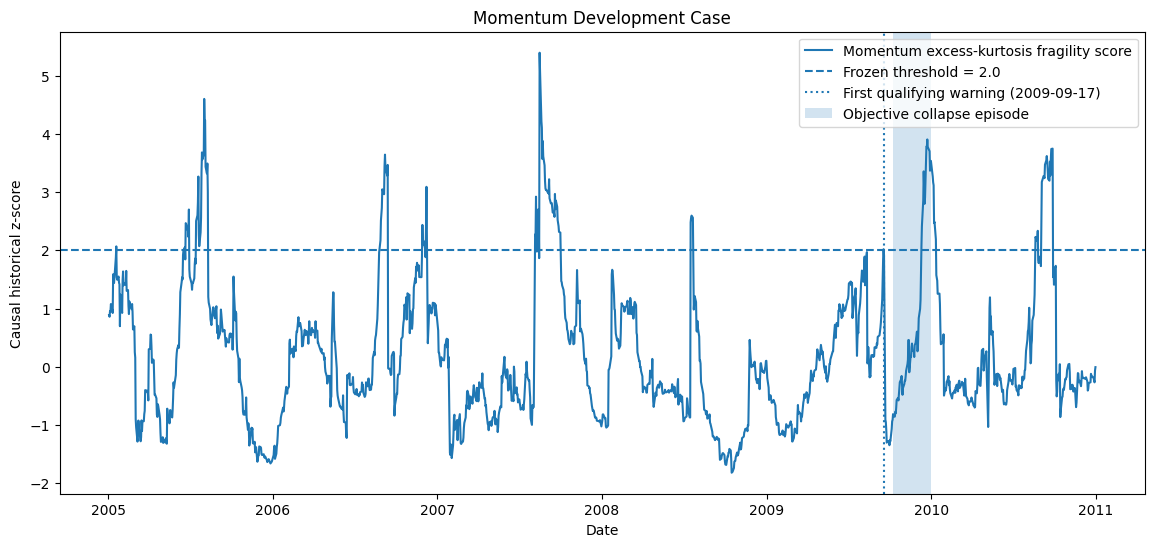

In [8]:
development_start = pd.Timestamp(
    "2005-01-01"
)

development_end = pd.Timestamp(
    "2010-12-31"
)

momentum_scores = (
    development_scores.loc[
        development_start:development_end,
        "excess_kurtosis",
    ]
)

development_event = (
    collapse_events.loc[
        (
            collapse_events["factor"]
            == "MOM"
        )
        & (
            collapse_events[
                "collapse_start"
            ]
            == DEVELOPMENT_COLLAPSE_START
        )
    ]
    .iloc[0]
)

development_warning = pd.Timestamp(
    frozen_config[
        "development_first_warning"
    ]
)

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.plot(
    momentum_scores.index,
    momentum_scores,
    label=(
        "Momentum excess-kurtosis "
        "fragility score"
    ),
)

ax.axhline(
    WARNING_THRESHOLD,
    linestyle="--",
    label=(
        f"Frozen threshold = "
        f"{WARNING_THRESHOLD:.1f}"
    ),
)

ax.axvline(
    development_warning,
    linestyle=":",
    label=(
        "First qualifying warning "
        f"({development_warning.date()})"
    ),
)

ax.axvspan(
    development_event[
        "collapse_start"
    ],
    development_event[
        "collapse_end"
    ],
    alpha=0.2,
    label="Objective collapse episode",
)

ax.set_xlabel("Date")

ax.set_ylabel(
    "Causal historical z-score"
)

ax.set_title(
    "Momentum Development Case"
)

ax.legend()

save_figure(
    fig,
    "figure_03_momentum_development",
)

plt.show()

Saved: figure_04_factor_recall.png
Saved: figure_04_factor_recall.pdf


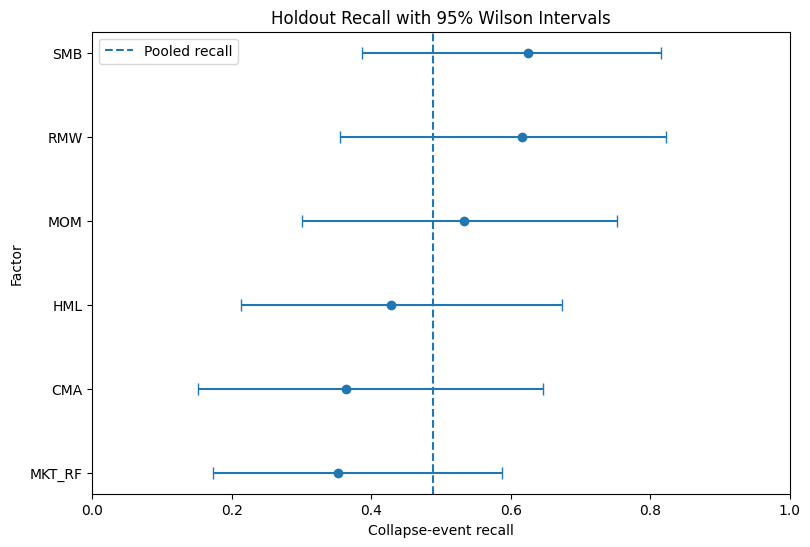

In [9]:
plot_data = (
    factor_validation
    .sort_values(
        "recall",
        ascending=True,
    )
    .reset_index(drop=True)
)

lower_error = (
    plot_data["recall"]
    - plot_data[
        "recall_ci_lower"
    ]
)

upper_error = (
    plot_data[
        "recall_ci_upper"
    ]
    - plot_data["recall"]
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.errorbar(
    plot_data["recall"],
    plot_data["factor"],
    xerr=np.vstack(
        [
            lower_error,
            upper_error,
        ]
    ),
    fmt="o",
    capsize=4,
)

ax.axvline(
    pooled_metrics.loc[0, "recall"],
    linestyle="--",
    label="Pooled recall",
)

ax.set_xlim(
    0,
    1,
)

ax.set_xlabel(
    "Collapse-event recall"
)

ax.set_ylabel("Factor")

ax.set_title(
    "Holdout Recall with 95% Wilson Intervals"
)

ax.legend()

save_figure(
    fig,
    "figure_04_factor_recall",
)

plt.show()

Saved: figure_05_precision_recall.png
Saved: figure_05_precision_recall.pdf


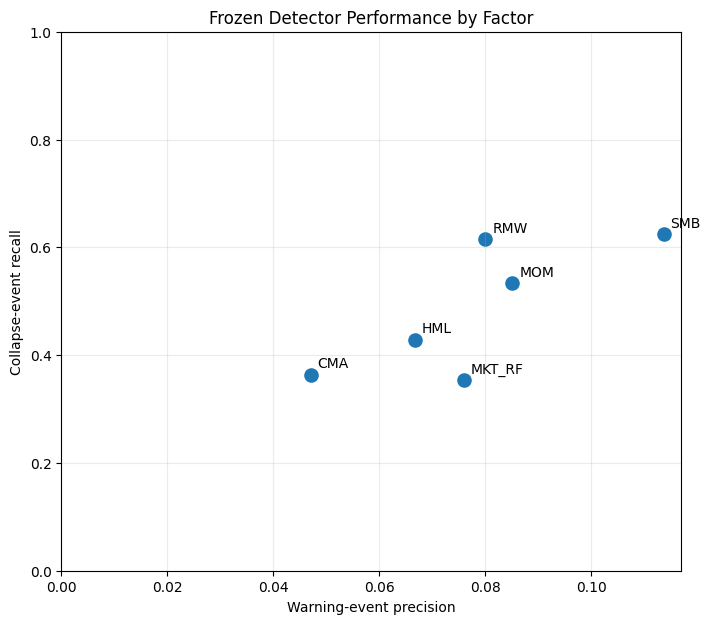

In [10]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.scatter(
    factor_metrics["precision"],
    factor_metrics["recall"],
    s=90,
)

for row in factor_metrics.itertuples(
    index=False
):
    ax.annotate(
        row.factor,
        (
            row.precision,
            row.recall,
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

ax.set_xlabel(
    "Warning-event precision"
)

ax.set_ylabel(
    "Collapse-event recall"
)

ax.set_title(
    "Frozen Detector Performance by Factor"
)

ax.set_xlim(
    left=0,
)

ax.set_ylim(
    0,
    1,
)

ax.grid(alpha=0.25)

save_figure(
    fig,
    "figure_05_precision_recall",
)

plt.show()

Saved: figure_06_lead_time_distribution.png
Saved: figure_06_lead_time_distribution.pdf


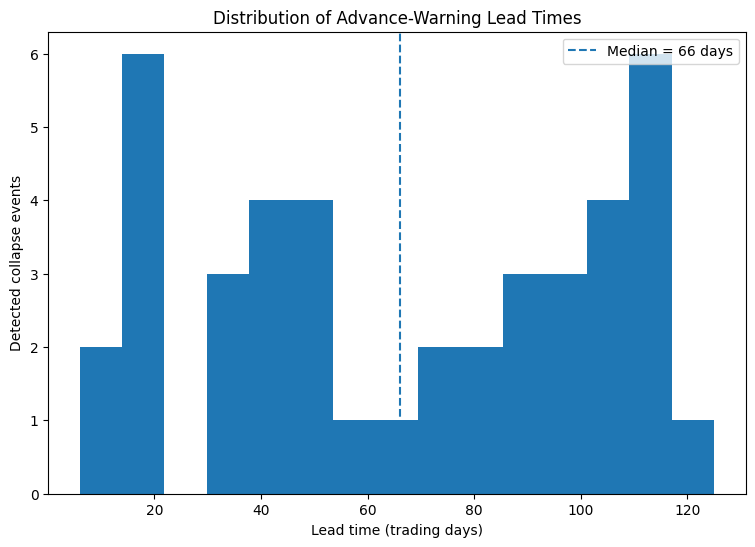

In [11]:
lead_times = (
    holdout_events.loc[
        holdout_events["detected"],
        "lead_time_days",
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.hist(
    lead_times,
    bins=15,
)

ax.axvline(
    lead_times.median(),
    linestyle="--",
    label=(
        f"Median = "
        f"{lead_times.median():.0f} days"
    ),
)

ax.set_xlabel(
    "Lead time (trading days)"
)

ax.set_ylabel(
    "Detected collapse events"
)

ax.set_title(
    "Distribution of Advance-Warning Lead Times"
)

ax.legend()

save_figure(
    fig,
    "figure_06_lead_time_distribution",
)

plt.show()

Saved: figure_07_null_recall.png
Saved: figure_07_null_recall.pdf


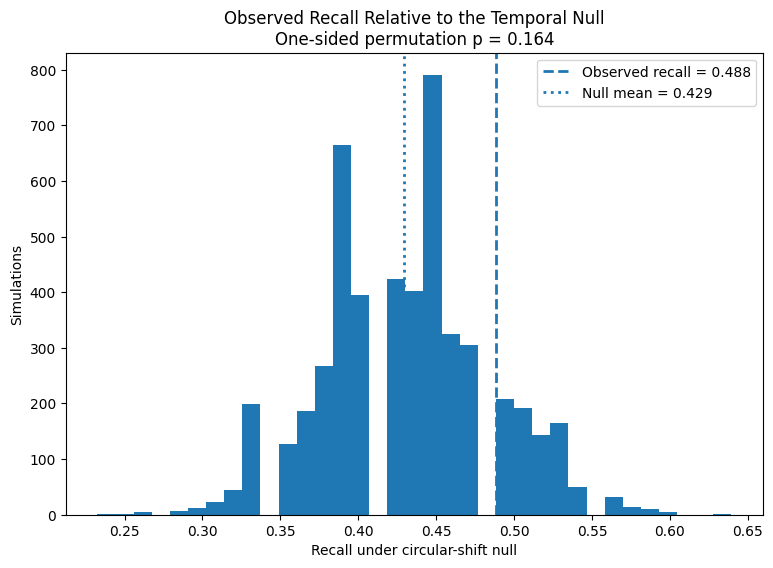

In [12]:
observed_recall = float(
    pooled_metrics.loc[0, "recall"]
)

null_recall = (
    null_distributions[
        "null_recall"
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.hist(
    null_recall,
    bins=35,
)

ax.axvline(
    observed_recall,
    linestyle="--",
    linewidth=2,
    label=(
        f"Observed recall = "
        f"{observed_recall:.3f}"
    ),
)

ax.axvline(
    null_recall.mean(),
    linestyle=":",
    linewidth=2,
    label=(
        f"Null mean = "
        f"{null_recall.mean():.3f}"
    ),
)

recall_pvalue = float(
    permutation_summary.loc[
        permutation_summary["metric"]
        == "recall",
        "permutation_pvalue",
    ].iloc[0]
)

ax.set_xlabel(
    "Recall under circular-shift null"
)

ax.set_ylabel("Simulations")

ax.set_title(
    "Observed Recall Relative to the Temporal Null\n"
    f"One-sided permutation p = {recall_pvalue:.3f}"
)

ax.legend()

save_figure(
    fig,
    "figure_07_null_recall",
)

plt.show()

Saved: figure_08_null_precision.png
Saved: figure_08_null_precision.pdf


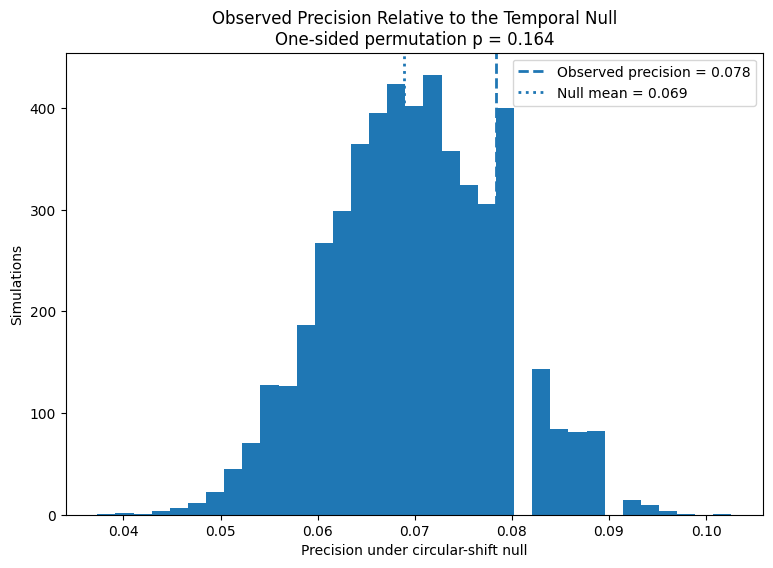

In [13]:
observed_precision = float(
    pooled_metrics.loc[0, "precision"]
)

null_precision = (
    null_distributions[
        "null_precision"
    ]
    .dropna()
)

precision_pvalue = float(
    permutation_summary.loc[
        permutation_summary["metric"]
        == "precision",
        "permutation_pvalue",
    ].iloc[0]
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.hist(
    null_precision,
    bins=35,
)

ax.axvline(
    observed_precision,
    linestyle="--",
    linewidth=2,
    label=(
        f"Observed precision = "
        f"{observed_precision:.3f}"
    ),
)

ax.axvline(
    null_precision.mean(),
    linestyle=":",
    linewidth=2,
    label=(
        f"Null mean = "
        f"{null_precision.mean():.3f}"
    ),
)

ax.set_xlabel(
    "Precision under circular-shift null"
)

ax.set_ylabel("Simulations")

ax.set_title(
    "Observed Precision Relative to the Temporal Null\n"
    f"One-sided permutation p = "
    f"{precision_pvalue:.3f}"
)

ax.legend()

save_figure(
    fig,
    "figure_08_null_precision",
)

plt.show()

Saved: figure_09_horizon_sensitivity.png
Saved: figure_09_horizon_sensitivity.pdf


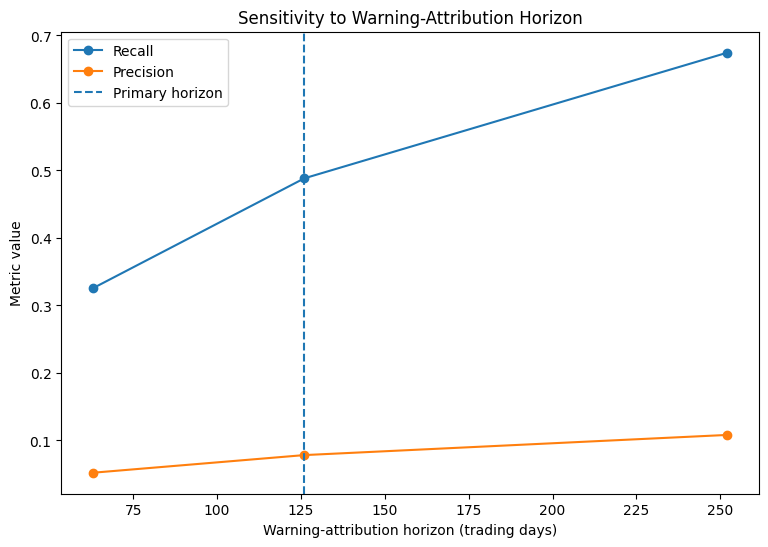

In [14]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.plot(
    horizon_sensitivity[
        "warning_horizon_days"
    ],
    horizon_sensitivity["recall"],
    marker="o",
    label="Recall",
)

ax.plot(
    horizon_sensitivity[
        "warning_horizon_days"
    ],
    horizon_sensitivity[
        "precision"
    ],
    marker="o",
    label="Precision",
)

ax.axvline(
    126,
    linestyle="--",
    label="Primary horizon",
)

ax.set_xlabel(
    "Warning-attribution horizon "
    "(trading days)"
)

ax.set_ylabel("Metric value")

ax.set_title(
    "Sensitivity to Warning-Attribution Horizon"
)

ax.legend()

save_figure(
    fig,
    "figure_09_horizon_sensitivity",
)

plt.show()

Saved: figure_10_vix_baseline_comparison.png
Saved: figure_10_vix_baseline_comparison.pdf


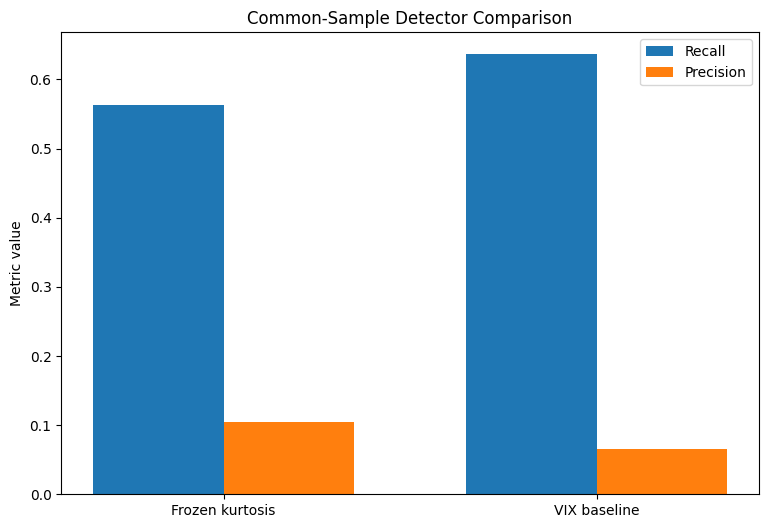

In [15]:
baseline_plot = (
    vix_baseline[
        [
            "detector",
            "recall",
            "precision",
        ]
    ]
    .copy()
)

x_positions = np.arange(
    len(baseline_plot)
)

bar_width = 0.35

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.bar(
    x_positions - bar_width / 2,
    baseline_plot["recall"],
    width=bar_width,
    label="Recall",
)

ax.bar(
    x_positions + bar_width / 2,
    baseline_plot["precision"],
    width=bar_width,
    label="Precision",
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    [
        "Frozen kurtosis",
        "VIX baseline",
    ]
)

ax.set_ylabel("Metric value")

ax.set_title(
    "Common-Sample Detector Comparison"
)

ax.legend()

save_figure(
    fig,
    "figure_10_vix_baseline_comparison",
)

plt.show()

Saved: figure_11_detector_overlap.png
Saved: figure_11_detector_overlap.pdf


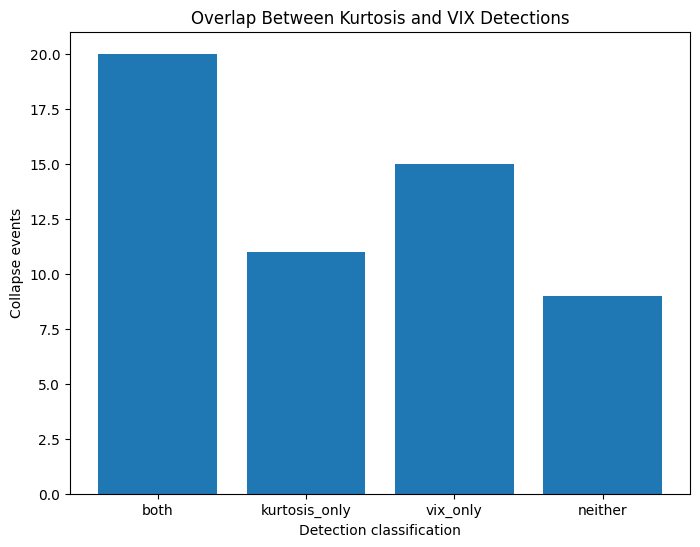

In [16]:
overlap_plot = (
    vix_overlap.copy()
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.bar(
    overlap_plot[
        "classification"
    ],
    overlap_plot[
        "event_count"
    ],
)

ax.set_xlabel(
    "Detection classification"
)

ax.set_ylabel(
    "Collapse events"
)

ax.set_title(
    "Overlap Between Kurtosis and VIX Detections"
)

save_figure(
    fig,
    "figure_11_detector_overlap",
)

plt.show()

Saved: figure_12_recall_sensitivity.png
Saved: figure_12_recall_sensitivity.pdf


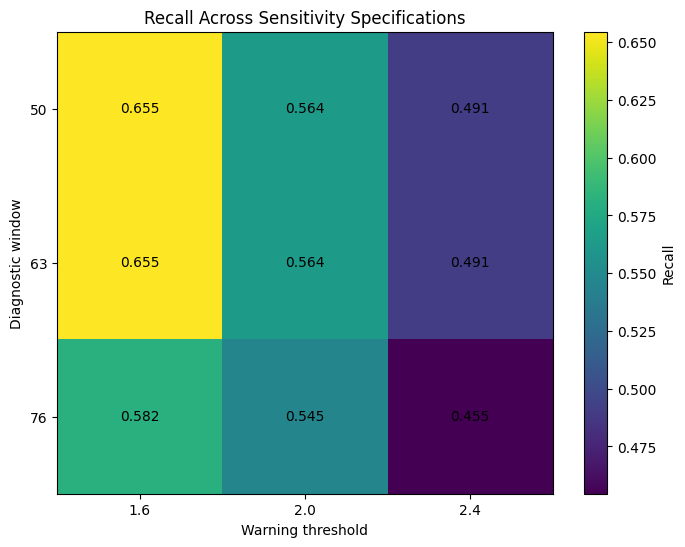

In [17]:
recall_pivot = (
    detector_sensitivity.pivot(
        index="diagnostic_window",
        columns="warning_threshold",
        values="recall",
    )
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

image = ax.imshow(
    recall_pivot.to_numpy(),
    aspect="auto",
)

ax.set_xticks(
    range(
        len(recall_pivot.columns)
    )
)

ax.set_xticklabels(
    recall_pivot.columns
)

ax.set_yticks(
    range(
        len(recall_pivot.index)
    )
)

ax.set_yticklabels(
    recall_pivot.index
)

ax.set_xlabel(
    "Warning threshold"
)

ax.set_ylabel(
    "Diagnostic window"
)

ax.set_title(
    "Recall Across Sensitivity Specifications"
)

for row_position in range(
    len(recall_pivot.index)
):
    for column_position in range(
        len(recall_pivot.columns)
    ):
        value = recall_pivot.iloc[
            row_position,
            column_position,
        ]

        ax.text(
            column_position,
            row_position,
            f"{value:.3f}",
            ha="center",
            va="center",
        )

fig.colorbar(
    image,
    ax=ax,
    label="Recall",
)

save_figure(
    fig,
    "figure_12_recall_sensitivity",
)

plt.show()

Saved: figure_13_precision_sensitivity.png
Saved: figure_13_precision_sensitivity.pdf


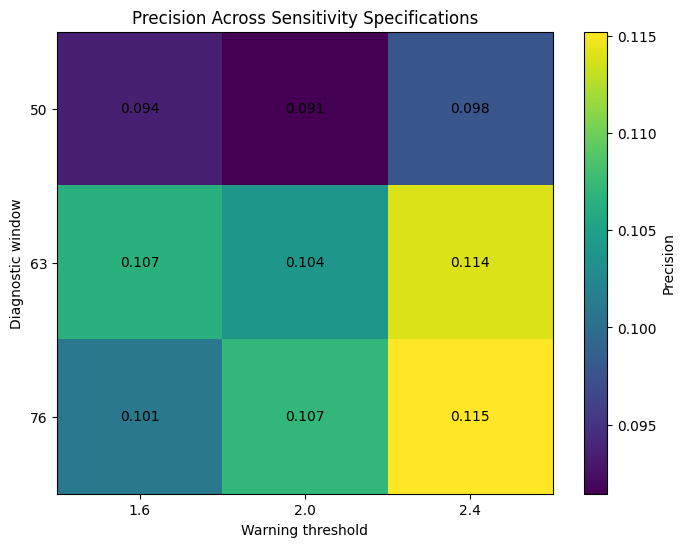

In [18]:
precision_pivot = (
    detector_sensitivity.pivot(
        index="diagnostic_window",
        columns="warning_threshold",
        values="precision",
    )
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

image = ax.imshow(
    precision_pivot.to_numpy(),
    aspect="auto",
)

ax.set_xticks(
    range(
        len(precision_pivot.columns)
    )
)

ax.set_xticklabels(
    precision_pivot.columns
)

ax.set_yticks(
    range(
        len(precision_pivot.index)
    )
)

ax.set_yticklabels(
    precision_pivot.index
)

ax.set_xlabel(
    "Warning threshold"
)

ax.set_ylabel(
    "Diagnostic window"
)

ax.set_title(
    "Precision Across Sensitivity Specifications"
)

for row_position in range(
    len(precision_pivot.index)
):
    for column_position in range(
        len(precision_pivot.columns)
    ):
        value = precision_pivot.iloc[
            row_position,
            column_position,
        ]

        ax.text(
            column_position,
            row_position,
            f"{value:.3f}",
            ha="center",
            va="center",
        )

fig.colorbar(
    image,
    ax=ax,
    label="Precision",
)

save_figure(
    fig,
    "figure_13_precision_sensitivity",
)

plt.show()

In [19]:
frozen_specification_table = pd.DataFrame(
    [
        {
            "Component":
                "Development factor",
            "Frozen specification":
                frozen_config[
                    "factor_used_for_development"
                ],
        },
        {
            "Component":
                "Development collapse",
            "Frozen specification":
                frozen_config[
                    "development_collapse_start"
                ],
        },
        {
            "Component":
                "Selected diagnostic",
            "Frozen specification":
                frozen_config[
                    "selected_diagnostics"
                ][0],
        },
        {
            "Component":
                "Diagnostic window",
            "Frozen specification":
                (
                    f"{frozen_config['diagnostic_window']} "
                    "trading days"
                ),
        },
        {
            "Component":
                "Standardization history",
            "Frozen specification":
                (
                    f"{frozen_config['zscore_reference_window']} "
                    "prior observations"
                ),
        },
        {
            "Component":
                "Warning threshold",
            "Frozen specification":
                frozen_config[
                    "warning_threshold"
                ],
        },
        {
            "Component":
                "Warning reset",
            "Frozen specification":
                (
                    f"{frozen_config['warning_reset_days']} "
                    "trading days"
                ),
        },
        {
            "Component":
                "Warning horizon",
            "Frozen specification":
                (
                    f"{frozen_config['warning_to_collapse_horizon_days']} "
                    "trading days"
                ),
        },
    ]
)

frozen_specification_table.to_csv(
    TABLES
    / "table_01_frozen_specification.csv",
    index=False,
)

frozen_specification_table

,Component,Frozen specification
0,Development factor,MOM
1,Development collapse,2009-10-07
2,Selected diagnostic,excess_kurtosis
3,Diagnostic window,63 trading days
4,Standardization history,252 prior observations
5,Warning threshold,2.0
6,Warning reset,5 trading days
7,Warning horizon,126 trading days


In [20]:
bootstrap_lookup = (
    bootstrap_summary
    .set_index("metric")
)

main_results_table = pd.DataFrame(
    [
        {
            "Metric":
                "Holdout collapse events",
            "Estimate":
                int(
                    pooled_metrics.loc[
                        0,
                        "holdout_collapse_events",
                    ]
                ),
            "95% CI":
                "—",
        },
        {
            "Metric":
                "Detected events",
            "Estimate":
                int(
                    pooled_metrics.loc[
                        0,
                        "detected_events",
                    ]
                ),
            "95% CI":
                "—",
        },
        {
            "Metric":
                "Recall",
            "Estimate":
                pooled_metrics.loc[
                    0,
                    "recall",
                ],
            "95% CI":
                (
                    f"{bootstrap_lookup.loc['recall', 'ci_lower']:.3f}"
                    "–"
                    f"{bootstrap_lookup.loc['recall', 'ci_upper']:.3f}"
                ),
        },
        {
            "Metric":
                "Warning-event precision",
            "Estimate":
                pooled_metrics.loc[
                    0,
                    "precision",
                ],
            "95% CI":
                (
                    f"{bootstrap_lookup.loc['precision', 'ci_lower']:.3f}"
                    "–"
                    f"{bootstrap_lookup.loc['precision', 'ci_upper']:.3f}"
                ),
        },
        {
            "Metric":
                "False-positive rate",
            "Estimate":
                pooled_metrics.loc[
                    0,
                    "false_positive_rate",
                ],
            "95% CI":
                "—",
        },
        {
            "Metric":
                "Median lead time",
            "Estimate":
                (
                    f"{pooled_metrics.loc[0, 'median_lead_time_days']:.0f} "
                    "trading days"
                ),
            "95% CI":
                (
                    f"{bootstrap_lookup.loc['median_lead_time_days', 'ci_lower']:.0f}"
                    "–"
                    f"{bootstrap_lookup.loc['median_lead_time_days', 'ci_upper']:.0f}"
                ),
        },
    ]
)

main_results_table.to_csv(
    TABLES
    / "table_02_main_holdout_results.csv",
    index=False,
)

main_results_table

,Metric,Estimate,95% CI
0,Holdout collapse events,86,—
1,Detected events,42,—
2,Recall,0.488372,0.384–0.593
3,Warning-event precision,0.078358,0.056–0.101
4,False-positive rate,0.921642,—
5,Median lead time,66 trading days,46–91


In [21]:
factor_results_table = (
    factor_metrics[
        [
            "factor",
            "collapse_events",
            "detected_events",
            "recall",
            "precision",
            "median_lead_time_days",
            "warnings_per_year",
        ]
    ]
    .merge(
        factor_validation[
            [
                "factor",
                "recall_ci_lower",
                "recall_ci_upper",
                "raw_permutation_pvalue",
                "bh_fdr_adjusted_pvalue",
                "bonferroni_adjusted_pvalue",
            ]
        ],
        on="factor",
        how="left",
        validate="one_to_one",
    )
)

factor_results_table.to_csv(
    TABLES
    / "table_03_factor_results.csv",
    index=False,
)

factor_results_table

,factor,collapse_events,detected_events,recall,precision,median_lead_time_days,warnings_per_year,recall_ci_lower,recall_ci_upper,raw_permutation_pvalue,bh_fdr_adjusted_pvalue,bonferroni_adjusted_pvalue
0,MKT_RF,17,6,0.352941,0.075949,64.0,1.255756,0.173097,0.586996,0.573285,0.687942,1.000000
1,SMB,16,10,0.625000,0.113636,78.0,1.398816,0.386410,0.815188,0.086983,0.521896,0.521896
2,HML,14,6,0.428571,0.066667,72.5,1.430608,0.213808,0.674094,0.564887,0.687942,1.000000
3,RMW,13,8,0.615385,0.080000,51.0,1.589564,0.355229,0.822903,0.217357,0.652070,1.000000
4,CMA,11,4,0.363636,0.047059,78.5,1.351129,0.151665,0.646199,0.818036,0.818036,1.000000
5,MOM,15,8,0.533333,0.085106,65.5,1.494190,0.301170,0.751905,0.440512,0.687942,1.000000


In [22]:
statistical_validation_table = (
    permutation_summary[
        [
            "metric",
            "observed",
            "null_mean",
            "null_median",
            "null_95th_percentile",
            "permutation_pvalue",
        ]
    ]
    .copy()
)

statistical_validation_table.to_csv(
    TABLES
    / "table_04_statistical_validation.csv",
    index=False,
)

statistical_validation_table

,metric,observed,null_mean,null_median,null_95th_percentile,permutation_pvalue
0,recall,0.488372,0.429342,0.430233,0.523256,0.164167
1,precision,0.078358,0.068887,0.069030,0.083955,0.164167


In [23]:
vix_comparison_table = (
    vix_baseline[
        [
            "detector",
            "collapse_events",
            "detected_events",
            "warning_events",
            "recall",
            "precision",
            "false_positive_rate",
            "median_lead_time_days",
            "common_sample_start",
            "common_sample_end",
        ]
    ]
    .copy()
)

vix_comparison_table.to_csv(
    TABLES
    / "table_05_vix_comparison.csv",
    index=False,
)

vix_comparison_table

,detector,collapse_events,detected_events,warning_events,recall,precision,false_positive_rate,median_lead_time_days,common_sample_start,common_sample_end
0,frozen_excess_kurtosis,55,31,298,0.563636,0.104027,0.895973,83.0,1990-12-31,2026-05-29
1,vix_level_zscore,55,35,540,0.636364,0.064815,0.935185,103.0,1990-12-31,2026-05-29


In [24]:
sensitivity_table = (
    detector_sensitivity[
        [
            "diagnostic_window",
            "warning_threshold",
            "is_frozen_primary",
            "recall",
            "precision",
            "false_positive_rate",
            "median_lead_time_days",
            "recall_change_from_primary",
            "precision_change_from_primary",
        ]
    ]
    .copy()
)

sensitivity_table.to_csv(
    TABLES
    / "table_06_detector_sensitivity.csv",
    index=False,
)

sensitivity_table

,diagnostic_window,warning_threshold,is_frozen_primary,recall,precision,false_positive_rate,median_lead_time_days,recall_change_from_primary,precision_change_from_primary
0,50,1.6,False,0.654545,0.093506,0.906494,82.0,0.090909,-0.010520
1,50,2.0,False,0.563636,0.091445,0.908555,76.0,0.000000,-0.012581
2,50,2.4,False,0.490909,0.097826,0.902174,73.0,-0.072727,-0.006201
3,63,1.6,False,0.654545,0.106509,0.893491,89.0,0.090909,0.002482
4,63,2.0,True,0.563636,0.104027,0.895973,83.0,0.000000,0.000000
5,63,2.4,False,0.490909,0.113924,0.886076,63.0,-0.072727,0.009897
6,76,1.6,False,0.581818,0.100946,0.899054,83.5,0.018182,-0.003080
7,76,2.0,False,0.545455,0.107143,0.892857,60.5,-0.018182,0.003116
8,76,2.4,False,0.454545,0.115207,0.884793,62.0,-0.109091,0.011181


In [25]:
figure_manifest = pd.DataFrame(
    [
        {
            "Figure": 1,
            "Filename":
                "figure_01_research_design",
            "Purpose":
                "Research sequence and safeguards",
        },
        {
            "Figure": 2,
            "Filename":
                "figure_02_collapse_timeline",
            "Purpose":
                "Objective collapse events over time",
        },
        {
            "Figure": 3,
            "Filename":
                "figure_03_momentum_development",
            "Purpose":
                "Development warning and collapse",
        },
        {
            "Figure": 4,
            "Filename":
                "figure_04_factor_recall",
            "Purpose":
                "Factor recall with uncertainty",
        },
        {
            "Figure": 5,
            "Filename":
                "figure_05_precision_recall",
            "Purpose":
                "Factor-level precision and recall",
        },
        {
            "Figure": 6,
            "Filename":
                "figure_06_lead_time_distribution",
            "Purpose":
                "Lead-time distribution",
        },
        {
            "Figure": 7,
            "Filename":
                "figure_07_null_recall",
            "Purpose":
                "Recall versus temporal null",
        },
        {
            "Figure": 8,
            "Filename":
                "figure_08_null_precision",
            "Purpose":
                "Precision versus temporal null",
        },
        {
            "Figure": 9,
            "Filename":
                "figure_09_horizon_sensitivity",
            "Purpose":
                "Evaluation-horizon sensitivity",
        },
        {
            "Figure": 10,
            "Filename":
                "figure_10_vix_baseline_comparison",
            "Purpose":
                "Kurtosis versus VIX",
        },
        {
            "Figure": 11,
            "Filename":
                "figure_11_detector_overlap",
            "Purpose":
                "Complementarity with VIX",
        },
        {
            "Figure": 12,
            "Filename":
                "figure_12_recall_sensitivity",
            "Purpose":
                "Recall parameter sensitivity",
        },
        {
            "Figure": 13,
            "Filename":
                "figure_13_precision_sensitivity",
            "Purpose":
                "Precision parameter sensitivity",
        },
    ]
)

figure_manifest.to_csv(
    FIGURES / "figure_manifest.csv",
    index=False,
)

figure_manifest

,Figure,Filename,Purpose
0,1,figure_01_research_design,Research sequence and safeguards
1,2,figure_02_collapse_timeline,Objective collapse events over time
2,3,figure_03_momentum_development,Development warning and collapse
3,4,figure_04_factor_recall,Factor recall with uncertainty
4,5,figure_05_precision_recall,Factor-level precision and recall
5,6,figure_06_lead_time_distribution,Lead-time distribution
6,7,figure_07_null_recall,Recall versus temporal null
7,8,figure_08_null_precision,Precision versus temporal null
8,9,figure_09_horizon_sensitivity,Evaluation-horizon sensitivity
9,10,figure_10_vix_baseline_comparison,Kurtosis versus VIX


In [26]:
expected_figure_files = [
    "figure_01_research_design",
    "figure_02_collapse_timeline",
    "figure_03_momentum_development",
    "figure_04_factor_recall",
    "figure_05_precision_recall",
    "figure_06_lead_time_distribution",
    "figure_07_null_recall",
    "figure_08_null_precision",
    "figure_09_horizon_sensitivity",
    "figure_10_vix_baseline_comparison",
    "figure_11_detector_overlap",
    "figure_12_recall_sensitivity",
    "figure_13_precision_sensitivity",
]

for filename in expected_figure_files:
    assert (
        FIGURES / f"{filename}.png"
    ).exists()

    assert (
        FIGURES / f"{filename}.pdf"
    ).exists()

expected_table_files = [
    "table_01_frozen_specification.csv",
    "table_02_main_holdout_results.csv",
    "table_03_factor_results.csv",
    "table_04_statistical_validation.csv",
    "table_05_vix_comparison.csv",
    "table_06_detector_sensitivity.csv",
]

for filename in expected_table_files:
    assert (
        TABLES / filename
    ).exists()

print(
    "✓ Every expected figure and table exists"
)

✓ Every expected figure and table exists


In [27]:
print("=" * 72)
print("PUBLICATION FIGURES AND TABLES COMPLETE")
print("=" * 72)

print(
    "Figures generated:",
    len(expected_figure_files),
)

print(
    "Tables generated:",
    len(expected_table_files),
)

print("\nFigure directory:")

for path in sorted(
    FIGURES.glob("*.png")
):
    print(" -", path.name)

print("\nTable directory:")

for path in sorted(
    TABLES.glob("*.csv")
):
    print(" -", path.name)

PUBLICATION FIGURES AND TABLES COMPLETE
Figures generated: 13
Tables generated: 6

Figure directory:
 - figure_01_research_design.png
 - figure_02_collapse_timeline.png
 - figure_03_momentum_development.png
 - figure_04_factor_recall.png
 - figure_05_precision_recall.png
 - figure_06_lead_time_distribution.png
 - figure_07_null_recall.png
 - figure_08_null_precision.png
 - figure_09_horizon_sensitivity.png
 - figure_10_vix_baseline_comparison.png
 - figure_11_detector_overlap.png
 - figure_12_recall_sensitivity.png
 - figure_13_precision_sensitivity.png

Table directory:
 - table_01_frozen_specification.csv
 - table_02_main_holdout_results.csv
 - table_03_factor_results.csv
 - table_04_statistical_validation.csv
 - table_05_vix_comparison.csv
 - table_06_detector_sensitivity.csv
